<h1 style="color:magenta;">NSL - Exercises 07 </h1>

### 16/4/2026
### Giulia Federica Bianca Coppi (84486A)

## Ex 1

I included the tail corrections for 
- the potential energy $U$ $$\frac{\langle V_{LJ}\rangle _{tail}}{N} = \frac{ 8 \pi \rho_{LJ} \varepsilon}{9 r_{c(LJ)}^9} - \frac{8 \pi \rho_{LJ} \varepsilon}{3 r_{c(LJ)}^3}$$
- the pressure $P$ $$\frac{\langle w_{LJ}\rangle _{tail}}{3N \varepsilon} = 32 \pi \rho_{LJ} \left[ \frac{1}{9 r_{c(LJ)}^9} - \frac{1}{6 r_{c(LJ)}^3}\right]$$

## Ex 2

The objective of this exercise is to determine the **optimal block size** for the data blocking method. This is essential to ensure that individual blocks are large enough to be statistically independent, thereby avoiding **autocorrelation** and providing a reliable estimation of the statistical uncertainties.

To achieve this, I performed two distinct simulations, MC and MD, recording the instantaneous values of the potential energy per particle $U/N$. 

The analysis is divided into two parts:
1. **Autocorrelation Function:** a Python script computes the autocorrelation decay to identify the typical correlation time.
2. **Uncertainty Evolution:** a second script evaluates how the statistical uncertainty changes as a function of the block size $L$, identifying the point where the error reaches a plateau.

The parameters used for the simulations are summarized in the following table (liquid phase):

| Parameter | Monte Carlo (MC) | Molecular Dynamics (MD) |
| :--- | :---: | :---: |
| **Number of particles** ($N$) | 108 | 108 |
| **Density** ($\rho^*$) | 0.8 | 0.8 |
| **Target Temperature** ($T^*$) | 1.1 | 1.1 (equilibrated from 2.0) |
| **Cut-off radius** ($r_{cut}$) | 2.5 | 2.5 |
| **Step size** ($\delta$) | 0.1 (50% acceptance) | 0.001 |
| **Total Steps** | $5 \times 10^5$ | $5 \times 10^5$ |
| **Initial Block size** | 1 step | 1 step |



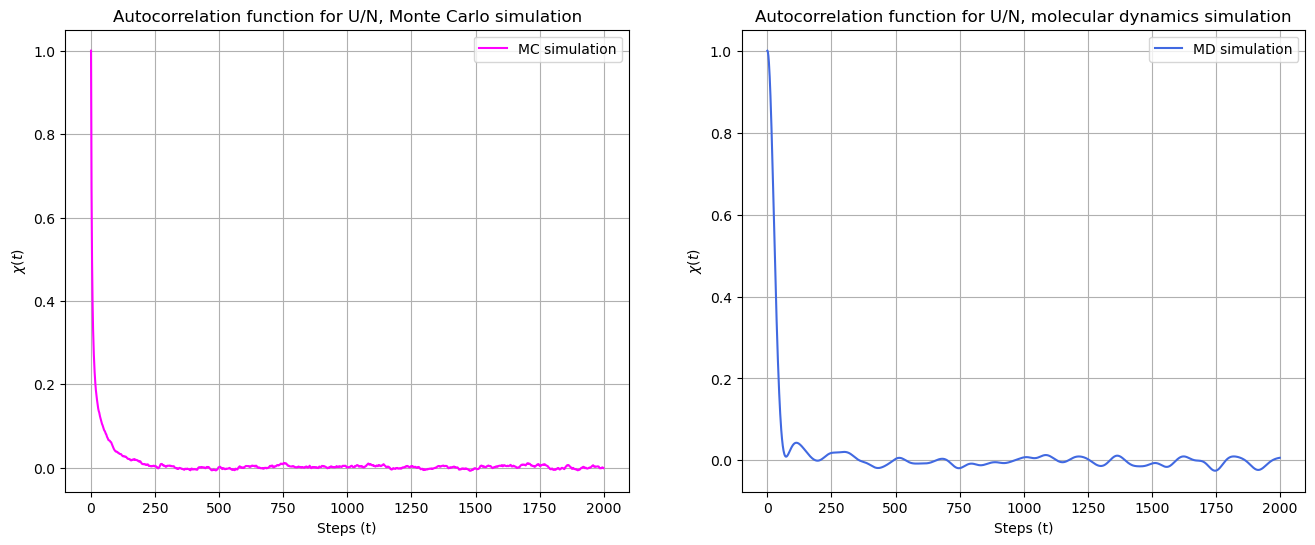

In [107]:
import numpy as np
import matplotlib.pyplot as plt

data_MC = np.loadtxt("./NSL_SIMULATOR/DATA_ANALYSIS/MC/potential_energy.dat")
data_MD = np.loadtxt("./NSL_SIMULATOR/DATA_ANALYSIS/MD/potential_energy.dat")
U_MC = data_MC[:, 1]
U_MD = data_MD[:, 1]

t_max = 500000
points = 2000

#mean and variance of the whole dataset -> fluctuations
mean_MC = np.mean(U_MC)
var_MC = np.var(U_MC)
fluctuation_U_MC = U_MC - mean_MC
mean_MD = np.mean(U_MD)
var_MD = np.var(U_MD)
fluctuation_U_MD = U_MD - mean_MD

#autocorrelation
autocorrelation_MC = []
autocorrelation_MD = []

for i in range(points):
    c_MC = np.dot(fluctuation_U_MC[:t_max-i], fluctuation_U_MC[i:t_max])
    autocorrelation_MC.append(c_MC / (t_max - i) / var_MC)
    c_MD = np.dot(fluctuation_U_MD[:t_max-i], fluctuation_U_MD[i:t_max])
    autocorrelation_MD.append(c_MD / (t_max - i) / var_MD)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

ax[0].plot(autocorrelation_MC, label = 'MC simulation', color = 'magenta')
ax[0].set_title("Autocorrelation function for U/N, Monte Carlo simulation")
ax[0].set_xlabel("Steps (t)")
ax[0].set_ylabel("$\chi(t)$")
ax[0].grid()
ax[0].legend()

ax[1].plot(autocorrelation_MD, label = 'MD simulation', color = 'royalblue')
ax[1].set_title("Autocorrelation function for U/N, molecular dynamics simulation")
ax[1].set_xlabel("Steps (t)")
ax[1].set_ylabel("$\chi(t)$")
ax[1].grid()
ax[1].legend()

plt.show()

As shown in the autocorrelation plots, the correlation is lost after approximately 300 steps for both simulation methods. 

To ensure that the Central Limit Theorem can be safely applied to our data blocking, we must choose a block size $L$ such that $L \gg \tau_c$. Therefore, a block size of 1000 steps is a robust choice, as it is large enough to treat the blocks as statistically independent, effectively avoiding the underestimation of uncertainties.

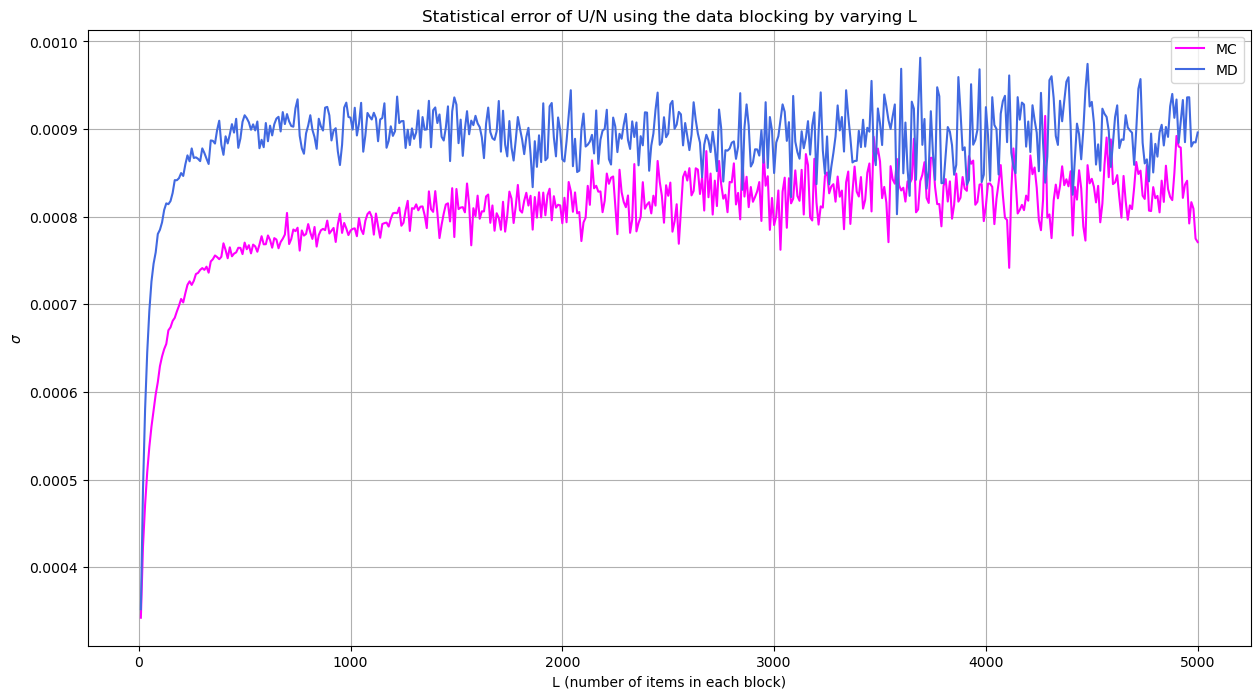

In [108]:
import numpy as np
import matplotlib.pyplot as plt

L_min = 10
L_max = 5000
N_tot = 500000

data_MC = np.loadtxt("./NSL_SIMULATOR/DATA_ANALYSIS/MC/potential_energy.dat")
data_MD = np.loadtxt("./NSL_SIMULATOR/DATA_ANALYSIS/MD/potential_energy.dat")
U_MC = data_MC[:, 1]
U_MD = data_MD[:, 1]

montecarlo_errors = np.zeros(500)
molecular_dynamics_errors = np.zeros(500)

#devo caricare i dati
#i dati devono essere divisi a gruppi di L
#quindi ho questi gruppi, ne devo calcolare media e varianza -> errore del blocco
#errore totale
#questo è un punto del grafico
#itera fino a L_max crescendo di 10

for L in range (10, 5001, 10):
    # Numero di blocchi completi
    M = N_tot // L #complete block, to avoid incomplete blocks (division between integers)
    
    matrix_MC = U_MC[:M*L].reshape(M, L) #matrix containing M rows (block) and L columns (items in the block)
    means_MC = np.mean(matrix_MC, axis=1) #array of M elements, each one is the mean of  block
    err_MC = np.sqrt(np.var(means_MC) / M) #statistical error for M=N/L blocks

    matrix_MD = U_MD[:M*L].reshape(M, L) #matrix containing M rows (block) and L columns (items in the block)
    means_MD = np.mean(matrix_MD, axis=1) #array of M elements, each one is the mean of  block
    err_MD = np.sqrt(np.var(means_MD) / M) #statistical error for M=N/L blocks

    i = (L // 10) - 1
    montecarlo_errors[i] = err_MC
    molecular_dynamics_errors[i] = err_MD

#plot
plt.figure(figsize=(15, 8))

L_values = np.arange(10, 5001, 10)

plt.plot(L_values, montecarlo_errors, label = 'MC', color = 'magenta')
plt.plot(L_values, molecular_dynamics_errors, label = 'MD', color = 'royalblue')
plt.title("Statistical error of U/N using the data blocking by varying L")
plt.xlabel("L (number of items in each block)")
plt.ylabel("$\sigma$")
plt.grid()
plt.legend()

plt.show()
    

The analysis of the statistical error as a function of block size $L$ shows that the uncertainty reaches a stable plateau at approximately $L=2000$. 

While the autocorrelation function decays significantly within the first 300 steps, the plateau identification provides a more rigorous bound for the statistical independence of the blocks. Consequently, for all subsequent simulations, I have set a block size of $L=2000$ steps for both MC and MD. This choice ensures that:
1. The autocorrelation between blocks is completely negligible.
2. The statistical uncertainties are estimated correctly and are not affected by underestimation due to residual correlations.

## Ex 3

I included the calculation of the radial distribution function $g(r)$ inside the NSL simulator code.
$$g(r)= \frac{1}{\rho N \Delta V(r)} \langle \sum \sum _{i\neq j =1}^N \delta \left[ |\vec{r}| - |(\vec{r}_i -\vec{r}_j)| \right]\rangle $$
where $$\Delta V(r)=\frac{4 \pi}{3} \left[(r+dr)^3 - r^3\right]$$ is the volume of the spherical shell in $[r, r+dr]$.

## Ex 4

I performed both simulations (after the equilibration) using the following parameters:

| Parameter | Monte Carlo (MC) | Molecular Dynamics (MD) |
| :--- | :---: | :---: |
| **Number of particles** ($N$) | 108 | 108 |
| **Density** ($\rho^*$) | 0.8 | 0.8 |
| **Target Temperature** ($T^*$) | 1.1 | 1.1 (equilibrated from 2.0) |
| **Cut-off radius** ($r_{cut}$) | 2.5 | 2.5 |
| **Step size** ($\delta$) | 0.1 (50% acceptance) | 0.001 |
| **Number of Blocks** | 250 | 250 |
| **Block size** | 2000 steps | 2000 steps |


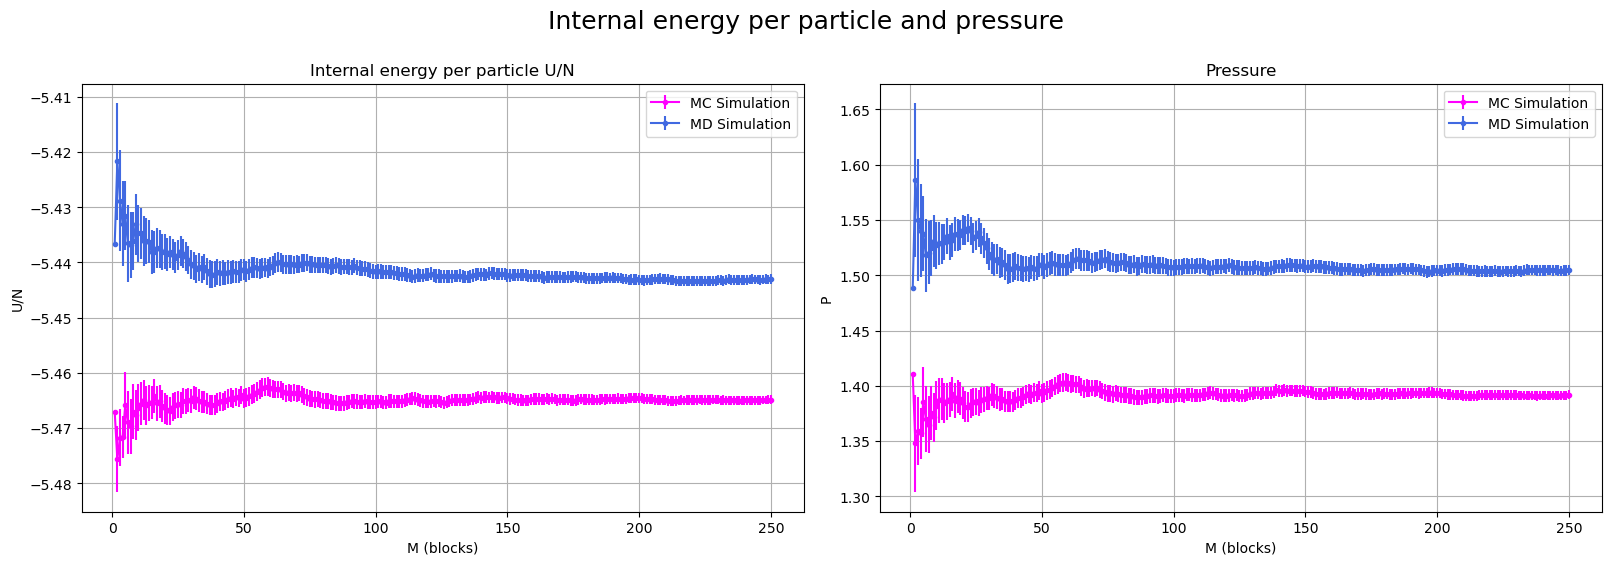

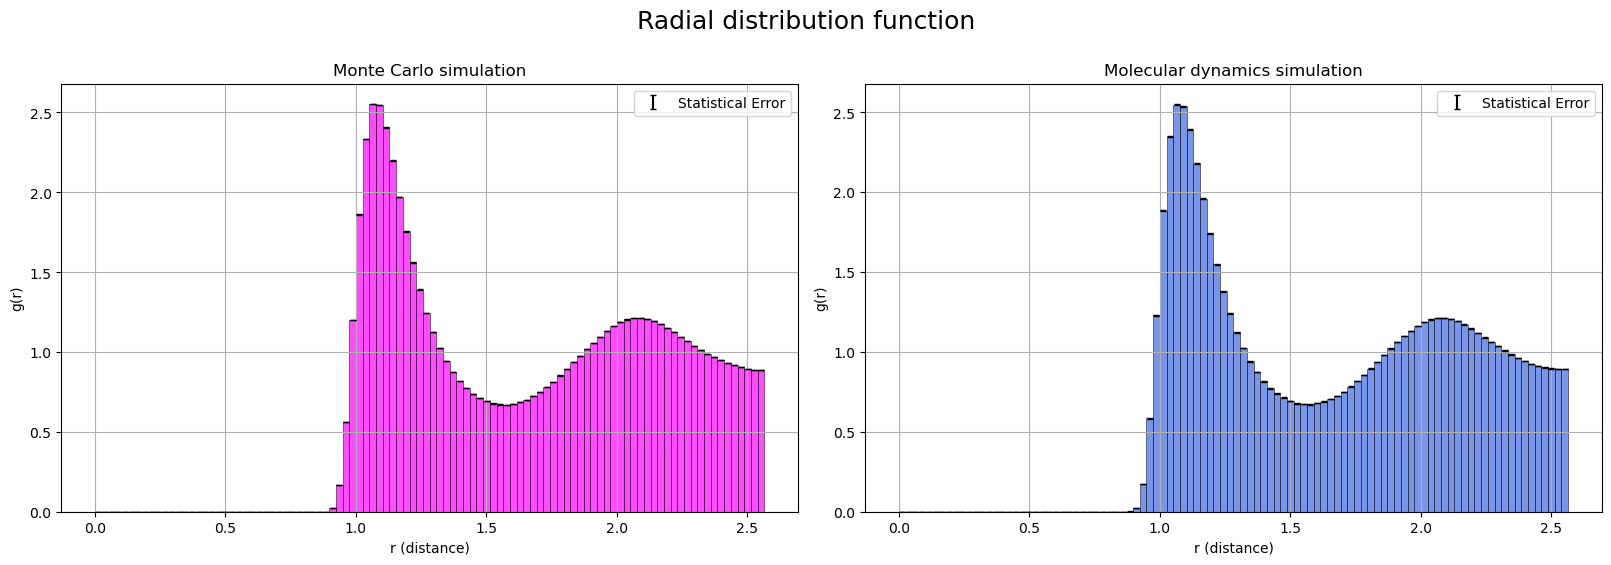

In [109]:
import numpy as np
import matplotlib.pyplot as plt

#U/N and P
data_U_MC = np.loadtxt("./NSL_SIMULATOR/DATA_ANALYSIS/MC/potential_energy_data_blocking.dat")
U_x_MC = data_U_MC[:, 0]
U_y_MC = data_U_MC[:, 2]
U_err_MC = data_U_MC[:, 3]

data_U_MD = np.loadtxt("./NSL_SIMULATOR/DATA_ANALYSIS/MD/potential_energy_data_blocking.dat")
U_x_MD = data_U_MD[:, 0]
U_y_MD = data_U_MD[:, 2]
U_err_MD = data_U_MD[:, 3]



data_P_MC = np.loadtxt("./NSL_SIMULATOR/DATA_ANALYSIS/MC/pressure_data_blocking.dat")
P_x_MC = data_P_MC[:, 0]
P_y_MC = data_P_MC[:, 2]
P_err_MC = data_P_MC[:, 3]

data_P_MD = np.loadtxt("./NSL_SIMULATOR/DATA_ANALYSIS/MD/pressure_data_blocking.dat")
P_x_MD = data_P_MD[:, 0]
P_y_MD = data_P_MD[:, 2]
P_err_MD = data_P_MD[:, 3]

fig, ax = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

plt.suptitle("Internal energy per particle and pressure", fontsize = 18, y=1.1)

ax[0].errorbar(U_x_MC, U_y_MC, yerr=U_err_MC, fmt='.-', color='magenta', label='MC Simulation')
ax[0].errorbar(U_x_MD, U_y_MD, yerr=U_err_MD, fmt='.-', color='royalblue', label='MD Simulation')
ax[0].set_title("Internal energy per particle U/N")
ax[0].set_xlabel("M (blocks)")
ax[0].set_ylabel("U/N")
ax[0].grid()
ax[0].legend()

ax[1].errorbar(P_x_MC, P_y_MC, yerr=P_err_MC, fmt='.-', color='magenta', label='MC Simulation')
ax[1].errorbar(P_x_MD, P_y_MD, yerr=P_err_MD, fmt='.-', color='royalblue', label='MD Simulation')
ax[1].set_title("Pressure")
ax[1].set_xlabel("M (blocks)")
ax[1].set_ylabel("P")
ax[1].grid()
ax[1].legend()

plt.show()


#g(r)
n_bins = 100

data_MC = np.loadtxt("./NSL_SIMULATOR/DATA_ANALYSIS/MC/gofr.dat")

final_data_MC = data_MC[-100:]
r_MC = final_data_MC[:, 0]
g_MC = final_data_MC[:, 1]
err_MC = final_data_MC[:, 2]

data_MD = np.loadtxt("./NSL_SIMULATOR/DATA_ANALYSIS/MD/gofr.dat")

final_data_MD = data_MD[-100:]
r_MD = final_data_MD[:, 0]
g_MD = final_data_MD[:, 1]
err_MD = final_data_MD[:, 2]

fig, ax = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

plt.suptitle("Radial distribution function", fontsize = 18, y=1.1)

ax[0].bar(r_MC, g_MC, width=(r_MC[1]-r_MC[0]), bottom=None, align='center', color='magenta', alpha=0.7, edgecolor='black', linewidth=0.5)
ax[0].errorbar(r_MC, g_MC, yerr=err_MC, fmt='none', ecolor='black', capsize=2, label='Statistical Error')
ax[0].set_title("Monte Carlo simulation")
ax[0].set_xlabel("r (distance)")
ax[0].set_ylabel("g(r)")
ax[0].grid()
ax[0].legend()

ax[1].bar(r_MD, g_MD, width=(r_MD[1]-r_MD[0]), bottom=None, align='center', color='royalblue', alpha=0.7, edgecolor='black', linewidth=0.5)
ax[1].errorbar(r_MD, g_MD, yerr=err_MD, fmt='none', ecolor='black', capsize=2, label='Statistical Error')
ax[1].set_title("Molecular dynamics simulation")
ax[1].set_xlabel("r (distance)")
ax[1].set_ylabel("g(r)")
ax[1].grid()
ax[1].legend()

plt.show()


### Pressure and Potential Energy

As observed in the plots, both methods yield very similar average values for pressure and potential energy per particle. However, the results are not perfectly compatible within their statistical uncertainties. This slight discrepancy can be attributed to the fact that MC and MD simulations sample the same thermodynamic ensemble only in the thermodynamic limit ($N \to \infty$). These minor divergences may also result from the high sensitivity of pressure to the average temperature.

### Radial Distribution Function
The two distributions appear identical and in perfect agreement with the expected theoretical behavior. 

The consistency between these results confirms that, despite the small differences in average pressure and energy, both methods correctly capture the microscopic structure of the system. 